In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.stats import spearmanr
from scipy.stats import pearsonr

### Extract Data

In [26]:
df_returns = pd.read_csv('C:\\Users\\Windows 10\\OneDrive\\Desktop\\Coding\\Stat Comp\\Project\\Data\\mag7_nasdaq_returns.csv')
df_returns.drop(columns=['Unnamed: 0'], inplace=True)
df_returns.head()

,AAPL,AMZN,WTI_Crude_Oil,Dollar_Index,COMEX_Gold,GOOGL,META,MSFT,NVDA,Treasury_Inflation,TSLA,Nasdaq,VIX_Fear_Index,Date
0,0.012364,0.010004,0.048509,-0.004895,0.004114,0.008064,0.007548,0.000965,0.022210,-0.000313,0.007317,0.009490,-0.060437,2021-01-05
1,-0.033662,-0.024897,0.014020,0.001006,-0.023455,-0.009868,-0.028269,-0.025929,-0.058953,-0.002975,0.028390,-0.006098,-0.010655,2021-01-06
2,0.034123,0.007577,0.003950,0.003351,0.002832,0.029869,0.020622,0.028457,0.057830,-0.000628,0.079447,0.025641,-0.107698,2021-01-07
3,0.008631,0.006496,0.027740,0.003006,-0.040893,0.013239,-0.004354,0.006093,-0.005040,-0.003928,0.078403,0.010293,-0.036209,2021-01-08
4,-0.023249,-0.021519,0.000191,0.004883,0.008451,-0.023106,-0.040102,-0.009699,0.025967,-0.002130,-0.078214,-0.012540,0.116883,2021-01-11


### Peason Correlation Measure

In [27]:
# Prepare a sorted DataFrame of correlations with Nasdaq for visualization
nasdaq_corr_sorted = (
    df_returns.drop(columns=['Date'], errors='ignore')
    .corr()[['Nasdaq']]
    .drop('Nasdaq')
    .reset_index()
    .rename(columns={'index': 'Feature', 'Nasdaq': 'Correlation'})
    .sort_values(by='Correlation', ascending=False)
)

In [28]:
# 2. Calculate Pearson correlation and p-value for each feature against Nasdaq, and store results in a list of dictionaries
results = []

cols_to_test = df_returns.drop(columns=['Nasdaq', 'Date'], errors='ignore').columns
for col in cols_to_test:
    corr, p_val = pearsonr(df_returns[col], df_returns['Nasdaq'])
    results.append({
        'Asset': col, 
        'Correlation': corr, 
        'P-value': p_val,
        'Linearity (P < 0.05)': 'Pass' if p_val < 0.05 else 'Fail'
    })

In [29]:
# Create a DataFrame to display the results
hypo_test_df = pd.DataFrame(results)
display(hypo_test_df)

,Asset,Correlation,P-value,Linearity (P < 0.05)
0,AAPL,0.778753,3.320625e-256,Pass
1,AMZN,0.776415,1.065891e-253,Pass
2,WTI_Crude_Oil,0.101205,3.276756e-04,Pass
3,Dollar_Index,-0.208833,7.645277e-14,Pass
4,COMEX_Gold,0.062106,2.773827e-02,Pass
5,GOOGL,0.741355,1.924281e-219,Pass
6,META,0.681363,3.762789e-172,Pass
7,MSFT,0.805227,6.712617e-287,Pass
8,NVDA,0.787303,1.233934e-265,Pass
9,Treasury_Inflation,0.173496,6.032316e-10,Pass


C:\Temp\ipykernel_848\755547570.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Correlation', y='Feature', data=nasdaq_corr_sorted, legend=False, palette='coolwarm')


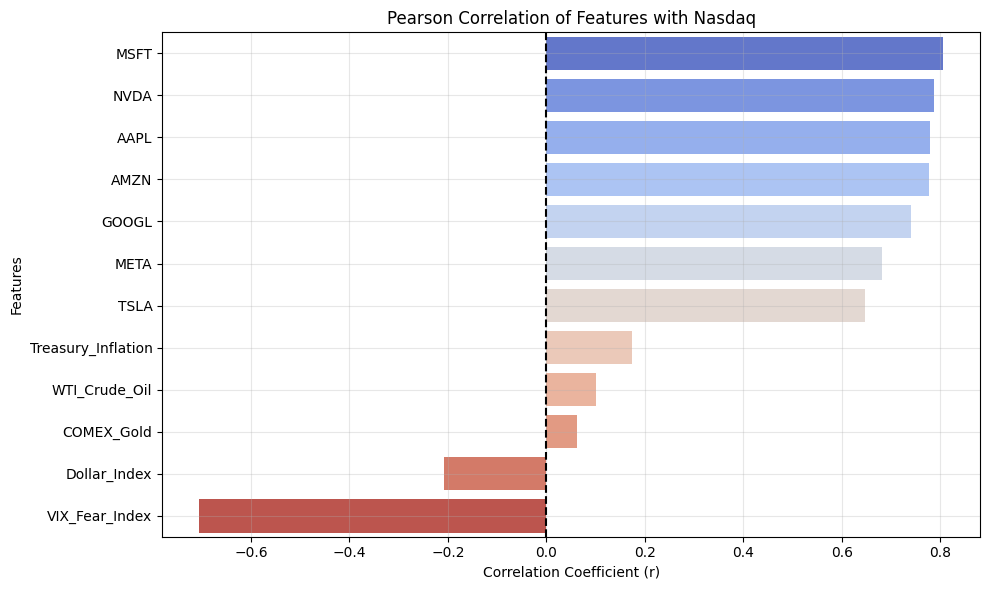

In [30]:
# Visualize the correlations with a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Correlation', y='Feature', data=nasdaq_corr_sorted, legend=False, palette='coolwarm')
plt.title('Pearson Correlation of Features with Nasdaq')
plt.xlabel('Correlation Coefficient (r)')
plt.ylabel('Features')
plt.axvline(x=0, color='black', linestyle='--')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Scatter Visualization

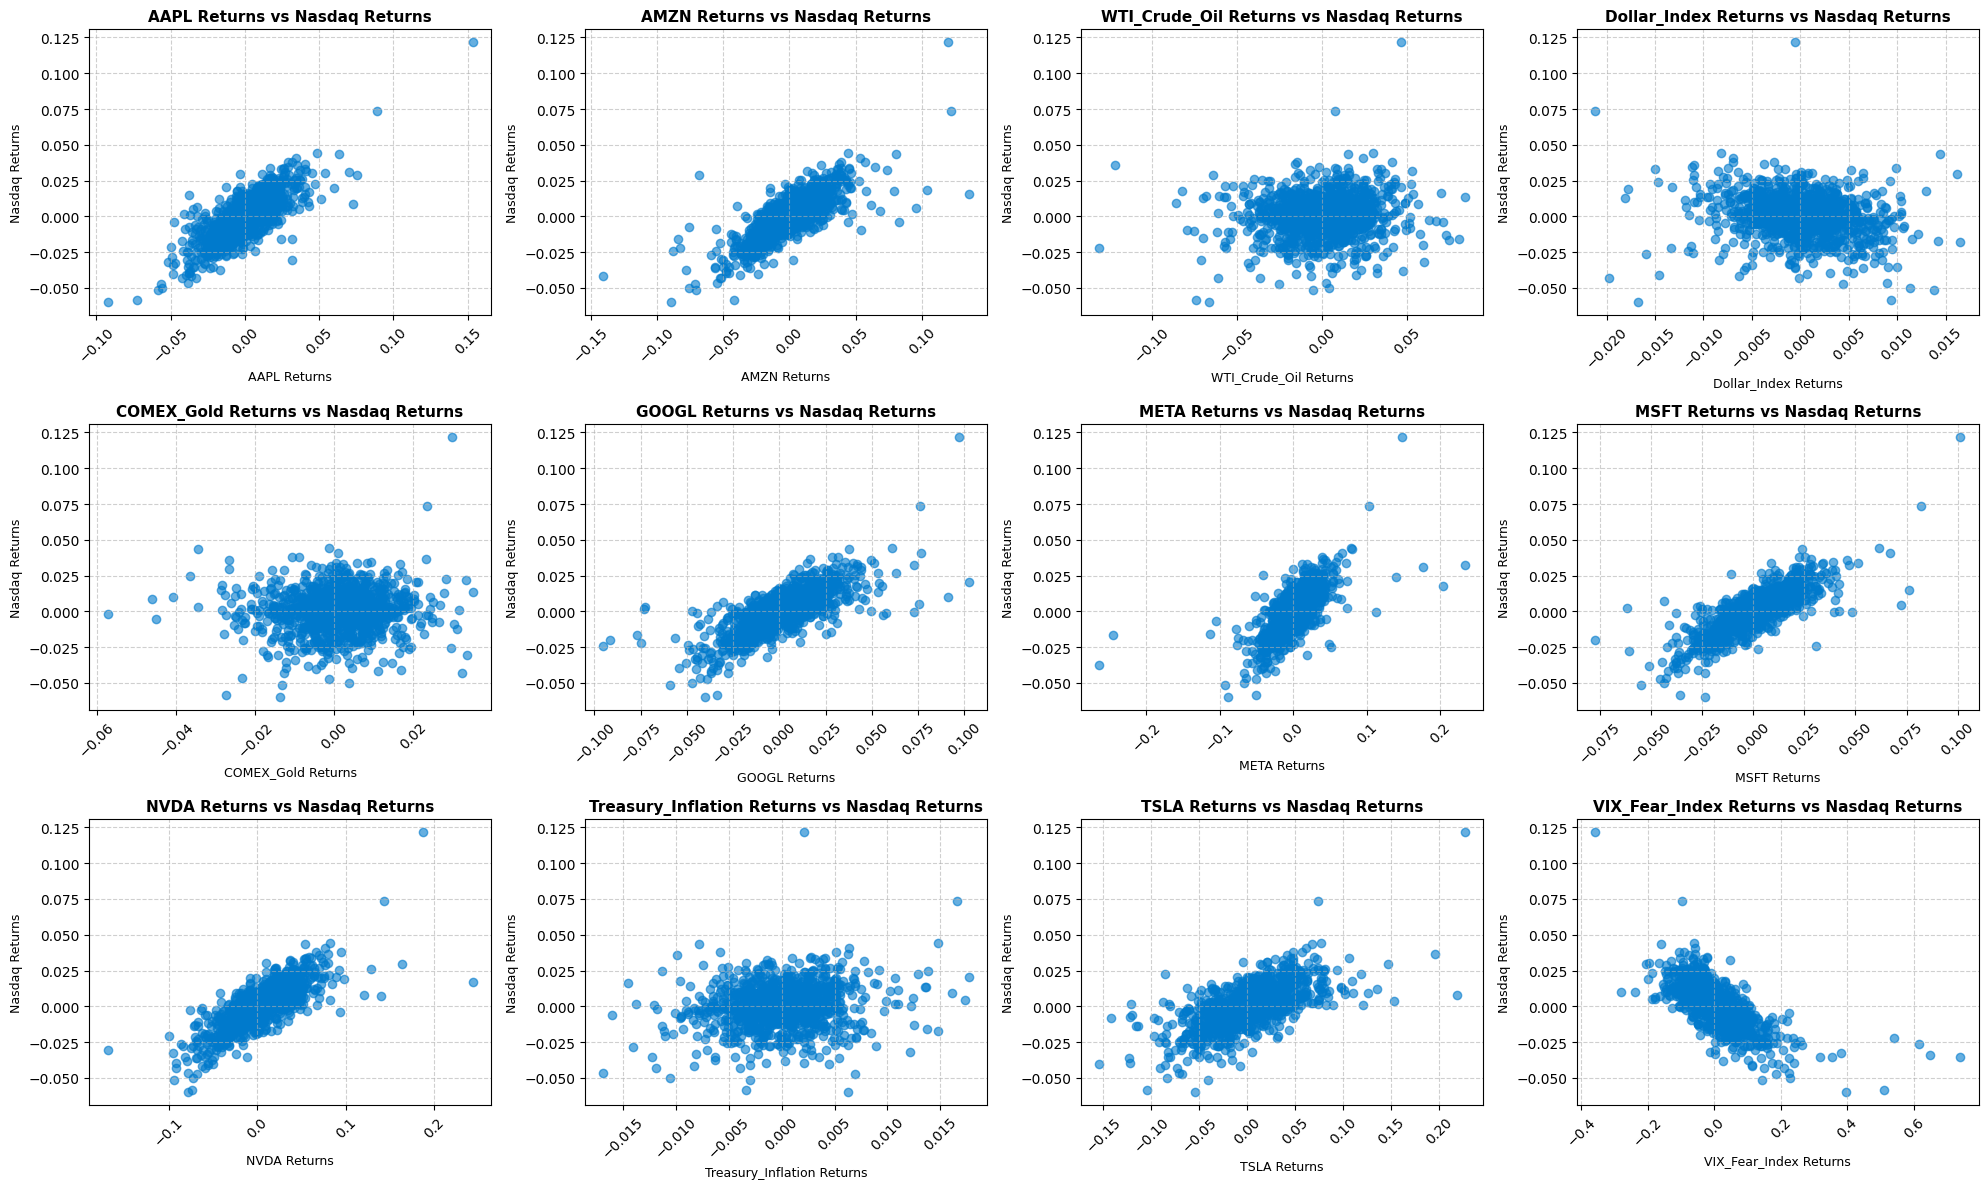

In [31]:
# Get all columns except Date
stocks = df_returns.drop(columns=['Date','Nasdaq']).columns

# Create subplots - 3 rows x 4 columns
n_cols = 4
n_rows = (len(stocks) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 12))
axes = axes.flatten()  # Flatten to 1D array for easier iteration

for idx, stock in enumerate(stocks):
    ax = axes[idx]
    ax.scatter(df_returns[stock], df_returns['Nasdaq'], color='#007acc', alpha=0.6)
    ax.set_title(f'{stock} Returns vs Nasdaq Returns', fontsize=11, fontweight='bold')
    ax.set_xlabel(f'{stock} Returns', fontsize=9)
    ax.set_ylabel('Nasdaq Returns', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.tick_params(axis='x', rotation=45)

# Hide any unused subplots
for idx in range(len(stocks), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

### Correlation Heatmap

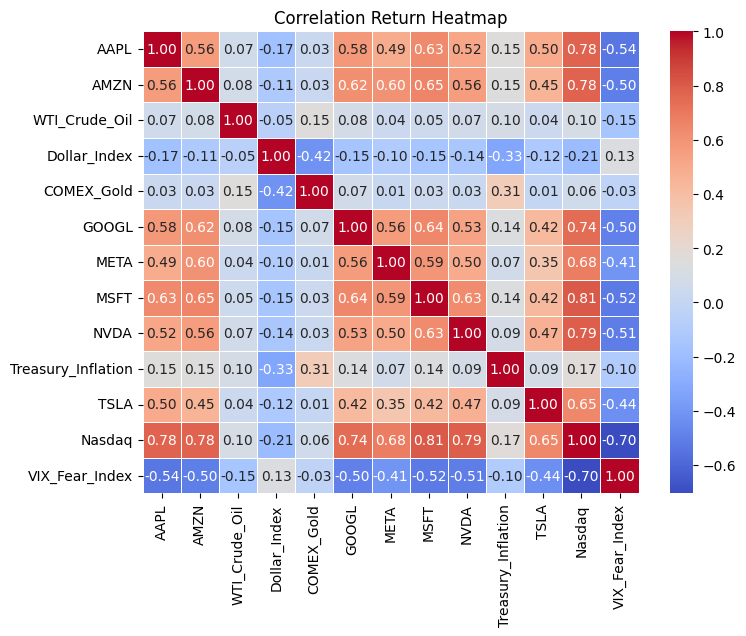

In [32]:
plt.figure(figsize=(8, 6))
correlation_matrix = df_returns.drop(columns=['Date']).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Return Heatmap')
plt.show()